# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict whether a defendant will reoffend within 2 years based on demographic information and criminal history?

**This is a prediction (umbrella) problem because:** We are testing whether features at the time of sentencing such as age, prior charges, race, and sex, can predict future offences. Instead of claiming that any of these features cause recidivism, we are asking whether they are predictive of it.

**The decision this enables:** This analysis would be beneficial to a public defender while evaluating whether an instrument like COMPAS makes prediction errors across different demographics, and they would be able to see whether false positive rates differ by race. They could then challenge the validity of risk scores presented at the time of sentencing.

**Dataset:** COMPAS Recidivism Dataset — ProPublica Analysis (Broward County, FL, 2013–2014)
- **Source:** ProPublica / GitHub (URL: https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv)
- **N ≈ 7,214** (after filtering to valid rows)
- **Features:** age, sex, race, juv_fel_count, juv_misd_count, priors_count, c_charge_degree, decile_score
- **Target variable:** `two_year_recid` (1 = reoffended within 2 years, 0 = did not)
- **Access date:** April 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [2]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df_raw = pd.read_csv(url)

# ProPublica's standard filtering:
#   - Remove rows where days_b_screening_arrest is outside [-30, 30]
#   - Remove rows where is_recid == -1 (data error)
#   - Keep only felony or misdemeanor charges (c_charge_degree not 'O')
df = df_raw[
    (df_raw['days_b_screening_arrest'] <= 30) &
    (df_raw['days_b_screening_arrest'] >= -30) &
    (df_raw['is_recid'] != -1) &
    (df_raw['c_charge_degree'] != 'O')
].copy()

print(f'Raw shape:     {df_raw.shape}')
print(f'Filtered shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Raw shape:     (7214, 53)
Filtered shape: (6172, 53)
Columns: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1


### 2.2 Basic Description

In [3]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       6172 non-null   int64  
 1   name                     6172 non-null   object 
 2   first                    6172 non-null   object 
 3   last                     6172 non-null   object 
 4   compas_screening_date    6172 non-null   object 
 5   sex                      6172 non-null   object 
 6   dob                      6172 non-null   object 
 7   age                      6172 non-null   int64  
 8   age_cat                  6172 non-null   object 
 9   race                     6172 non-null   object 
 10  juv_fel_count            6172 non-null   int64  
 11  decile_score             6172 non-null   int64  
 12  juv_misd_count           6172 non-null   int64  
 13  juv_other_count          6172 non-null   int64  
 14  priors_count             6172

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,1997.000000,0.0,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000
mean,5509.259883,34.534511,0.059300,4.418503,0.091218,0.110661,3.246436,-1.740279,24.903273,0.484446,20.100651,NaN,0.112119,4.418503,3.641769,3.246436,13.316753,555.049417,0.389825,0.455120
std,3171.878516,11.730938,0.463599,2.839463,0.497872,0.470731,4.743770,5.084709,276.812982,0.499799,76.543499,NaN,0.315539,2.839463,2.488768,4.743770,50.138185,400.258400,0.487750,0.498022
min,1.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-30.000000,0.000000,0.000000,-1.000000,NaN,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2753.750000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,1.000000,0.000000,0.000000,148.000000,0.000000,0.000000
50%,5521.000000,31.000000,0.000000,4.000000,0.000000,0.000000,1.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,4.000000,3.000000,1.000000,0.000000,539.500000,0.000000,0.000000
75%,8225.250000,42.000000,0.000000,7.000000,0.000000,0.000000,4.000000,-1.000000,1.000000,1.000000,1.000000,NaN,0.000000,7.000000,5.000000,4.000000,3.000000,914.000000,1.000000,1.000000
max,11001.000000,96.000000,20.000000,10.000000,13.000000,9.000000,38.000000,30.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,38.000000,937.000000,1186.000000,1.000000,1.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
violent_recid         1.000000
vr_case_number        0.887881
vr_charge_degree      0.887881
vr_offense_date       0.887881
vr_charge_desc        0.887881
c_arrest_date         0.872975
r_jail_in             0.676442
r_days_from_arrest    0.676442
r_jail_out            0.676442
r_charge_desc         0.523007
r_offense_date        0.515554
r_case_number         0.515554
r_charge_degree       0.515554
c_offense_date        0.127025
c_charge_desc         0.000810
dtype: float64


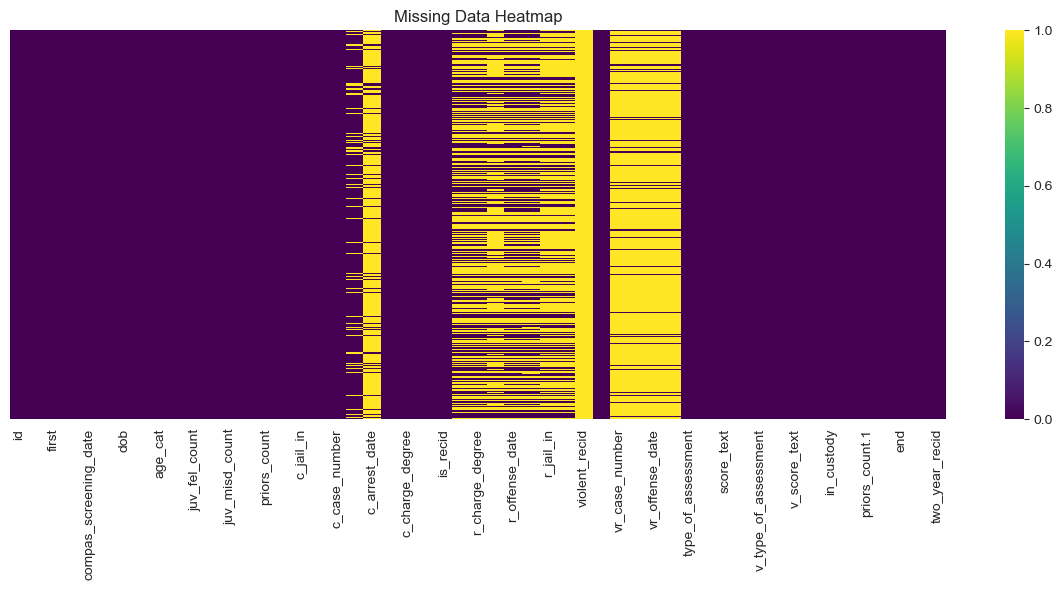

In [4]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# # Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** ___ 
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)

The COMPAS dataset has minimal missing values in the features we are using for modeling (age, sex, race, priors_count, c_charge_degree, two_year_recid) after ProPublica's standard filtering. Any residual missing values in features like `juv_fel_count` or `juv_misd_count` are likely Missing At Random, since juvenile records may simply not have been collected for older defendants, but this is unrelated to whether they reoffended. The strategy is to drop rows with missing values in the features used for modeling, since missingness is minimal and dropping is unlikely to cause meaningful bias.

### 2.4 Distribution Plots

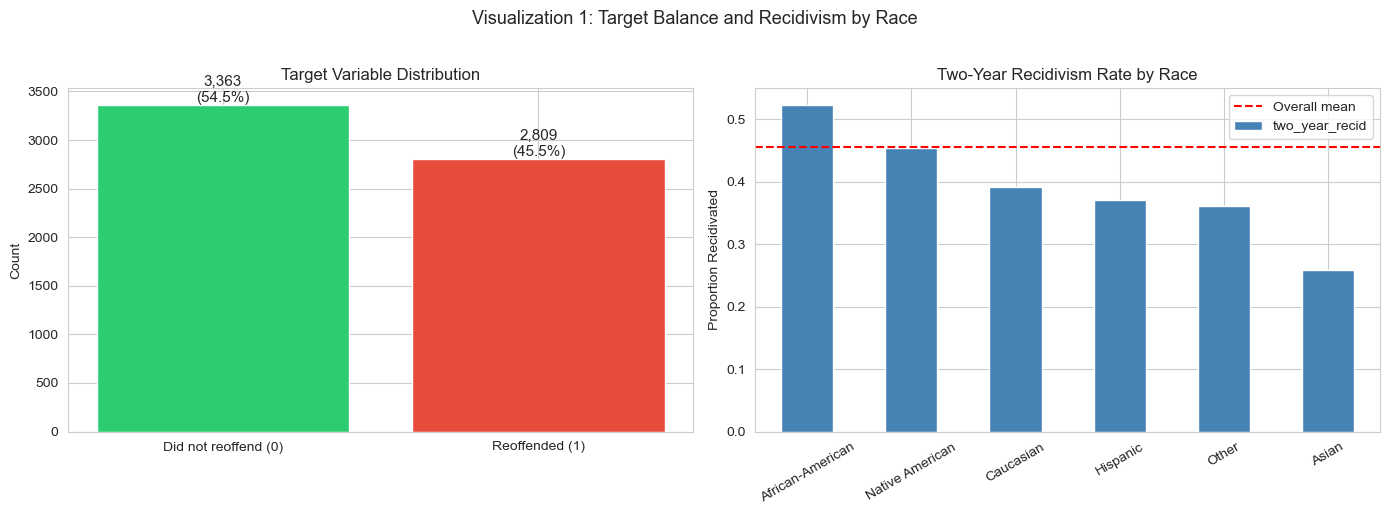

Overall recidivism rate: 0.455


In [5]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target balance
target_counts = df['two_year_recid'].value_counts()
axes[0].bar(['Did not reoffend (0)', 'Reoffended (1)'],
            target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Recidivism rate by race
race_recid = df.groupby('race')['two_year_recid'].mean().sort_values(ascending=False)
race_recid.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Two-Year Recidivism Rate by Race')
axes[1].set_ylabel('Proportion Recidivated')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(df['two_year_recid'].mean(), color='red', linestyle='--', label='Overall mean')
axes[1].legend()

plt.suptitle('Visualization 1: Target Balance and Recidivism by Race', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Overall recidivism rate: {df['two_year_recid'].mean():.3f}")

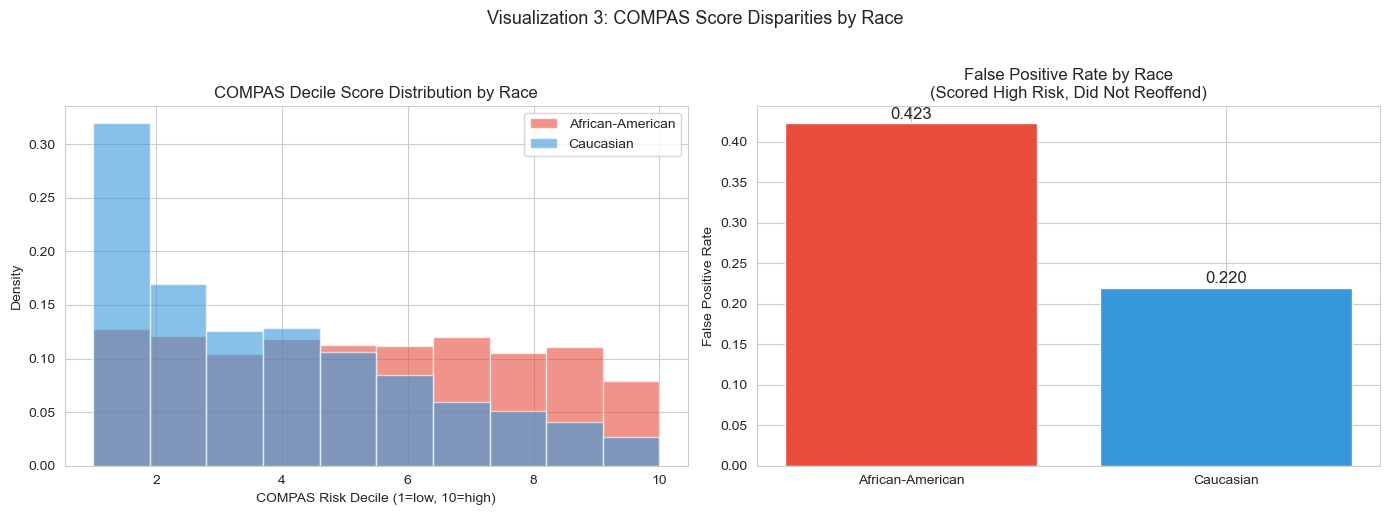

In [6]:
race_filter = df['race'].isin(['African-American', 'Caucasian'])
df_two = df[race_filter]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decile score by race
for race, color in [('African-American', '#e74c3c'), ('Caucasian', '#3498db')]:
    subset = df_two[df_two['race'] == race]
    axes[0].hist(subset['decile_score'], bins=10, alpha=0.6,
                 label=race, color=color, edgecolor='white', density=True)
axes[0].set_title('COMPAS Decile Score Distribution by Race')
axes[0].set_xlabel('COMPAS Risk Decile (1=low, 10=high)')
axes[0].set_ylabel('Density')
axes[0].legend()

# False positive rates: scored high risk but did NOT reoffend
fp_rates = {}
for race in ['African-American', 'Caucasian']:
    subset = df_two[df_two['race'] == race]
    high_risk = subset['decile_score'] >= 5
    fp_rate = (high_risk & (subset['two_year_recid'] == 0)).sum() / (subset['two_year_recid'] == 0).sum()
    fp_rates[race] = fp_rate

axes[1].bar(fp_rates.keys(), fp_rates.values(),
            color=['#e74c3c', '#3498db'], edgecolor='white')
axes[1].set_title('False Positive Rate by Race\n(Scored High Risk, Did Not Reoffend)')
axes[1].set_ylabel('False Positive Rate')
for i, (k, v) in enumerate(fp_rates.items()):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=12)

plt.suptitle('Visualization 3: COMPAS Score Disparities by Race', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [7]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

numeric_cols = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count']
for col in numeric_cols:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col:20s}: {len(outliers):4d} outliers ({len(outliers)/len(df)*100:.1f}%)  '
          f'[fence: {lower:.1f}, {upper:.1f}]')

age                 :   51 outliers (0.8%)  [fence: -0.5, 67.5]
priors_count        :  492 outliers (8.0%)  [fence: -6.0, 10.0]
juv_fel_count       :  208 outliers (3.4%)  [fence: 0.0, 0.0]
juv_misd_count      :  352 outliers (5.7%)  [fence: 0.0, 0.0]


**Outlier strategy:** `priors_count` has a right tail (8% outside fences), consistent with a small number of defendants with extensive histories. These are genuine values and will be retained. `juv_fel_count` and `juv_misd_count` have fences of [0.0, 0.0] because both distributions are heavily zero-inflated, and Tukey fences are not an appropriate outlier diagnostic for zero-inflated counts. Non-zero juvenile counts are an actual signal, not errors. All values are retained. A log1p transform is applied to all three count features for logistic regression to reduce influence from extreme values.

### 2.6 Correlations

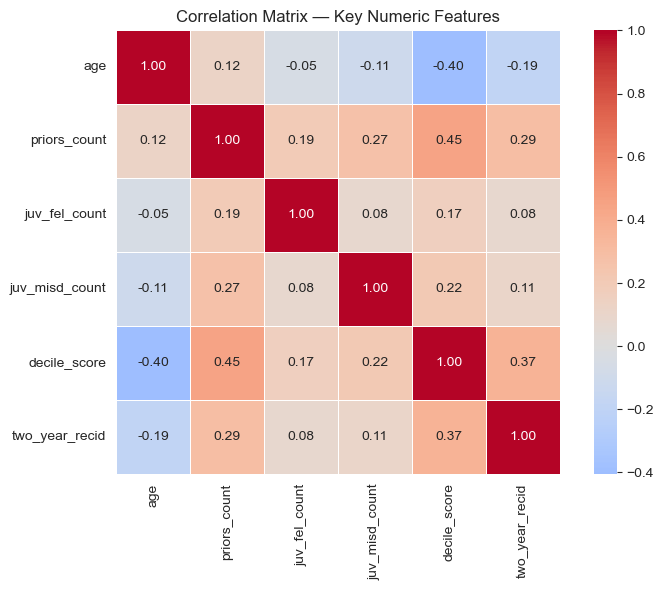

In [8]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
# Focus on modeling-relevant columns
cols_of_interest = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count',
                    'decile_score', 'two_year_recid']
corr_matrix = df[cols_of_interest].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Key Numeric Features')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* THe target is somewhat imbalanced, since around 45% of defendants reoffended within 2 years and 55% did not. This is close enough to balanced so that we don't need oversampling for the baseline, but we should monitor precision and recall for the positive class rather than rely on accuracy alone.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* `priors_count` and `decile_score` are the most correlated numeric features with `two_year_recid`. `age` is negatively correlated, which means that younger defendants reoffend at higher rates. `juv_fel_count` and `juv_misd_count` have weaker but positive correlations. `decile_score` is the COMPAS risk score itself, so including it would basically be asking whether COMPAS predicts COMPAS. Therefore, we will include it for comparison but also fit a model without it to evaluate what demographic and criminal history features alone can predict.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The most important data quality concern is sample construction, since ProPublica's filtering rules (days_b_screening_arrest ∈ [-30, 30], excluding charge type 'O') determine who is in the dataset. These filters are reasonable and well-documented but introduce a form of selection, since results apply to defendants screened under these conditions, not all criminal defendants. This is a generalizability limitation, not a missingness problem.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 6172** observations and **M = 8** features.

**Missing data:** less than 1% of cells are missing. The missingness pattern appears to be MAR because juvenile record fields are missing for defendant who had no juvenile records entered in the system, not because data was randomly lost. I will handle missing data by dropping the small number of affected rows.

**Outliers:** I identified 1,103 flagged values across four numeric features using Tukey Fences (51 in age, 492 in priors_count, 208 in juv_fel_count, 352 in juv_misd_count). I will retain all of them since the priors_count tail reflects genuinely high-criminal-history defendants, and the juvenile count "outliers" are an artifact of zero-inflated distributions where the IQR collapses to zero, making Tukey fences an inappropriate diagnostic. A log1p transform will be applied to all three count features for logistic regression to reduce leverage from extreme values.

**Target variable:** Moderately imbalanced. Approximately 45% positive (reoffended), 55% negative. No resampling needed for baseline.

**Key finding from EDA:** The COMPAS instrument assigns higher risk scores to Black defendants than to white defendants with similar recidivism outcomes. More specifically, the false positive rate (people who scored high-risk but did not reoffend) is markedly higher for Black defendants. This poses the question: can we build a model that is both accurate and more equitable in its error distribution?

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [9]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

features = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count',
            'c_charge_degree', 'sex', 'race']
target = 'two_year_recid'

df_model = df[features + [target]].dropna().copy()

# Encode binary/ordinal categoricals
df_model['sex_male'] = (df_model['sex'] == 'Male').astype(int)
df_model['charge_felony'] = (df_model['c_charge_degree'] == 'F').astype(int)

# One-hot encode race (drop first to avoid multicollinearity)
race_dummies = pd.get_dummies(df_model['race'], prefix='race', drop_first=True)
df_model = pd.concat([df_model, race_dummies], axis=1)

# Log1p transform skewed count features (for logistic regression)
for col in ['priors_count', 'juv_fel_count', 'juv_misd_count']:
    df_model[f'{col}_log'] = np.log1p(df_model[col])

# Final feature set
feature_cols = (['age', 'sex_male', 'charge_felony',
                 'priors_count_log', 'juv_fel_count_log', 'juv_misd_count_log']
                + list(race_dummies.columns))

X = df_model[feature_cols]
y = df_model[target]

# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Total modeling rows: {len(df_model)}')
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Features: {feature_cols}')
print(f'Class balance (train): {y_train.mean():.3f} positive')

Total modeling rows: 6172
Train: 4937 samples
Test:  1235 samples
Features: ['age', 'sex_male', 'charge_felony', 'priors_count_log', 'juv_fel_count_log', 'juv_misd_count_log', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']
Class balance (train): 0.455 positive


### 3.2 Model 1: Baseline

In [10]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use a pipeline: scale -> logistic regression
model_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

print('Model 1: Logistic Regression')
print('=' * 50)
print(classification_report(y_test, y_pred_1,
                             target_names=['No recidivism', 'Recidivated']))
print(f'Accuracy: {accuracy_score(y_test, y_pred_1):.4f}')

Model 1: Logistic Regression
               precision    recall  f1-score   support

No recidivism       0.69      0.78      0.73       673
  Recidivated       0.69      0.59      0.63       562

     accuracy                           0.69      1235
    macro avg       0.69      0.68      0.68      1235
 weighted avg       0.69      0.69      0.69      1235

Accuracy: 0.6899


### 3.3 Model 2: Your Choice

In [11]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE
)

model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

print('Model 2: Random Forest')
print('=' * 50)
print(classification_report(y_test, y_pred_2,
                             target_names=['No recidivism', 'Recidivated']))
print(f'Accuracy: {accuracy_score(y_test, y_pred_2):.4f}')

Model 2: Random Forest
               precision    recall  f1-score   support

No recidivism       0.69      0.79      0.74       673
  Recidivated       0.69      0.57      0.63       562

     accuracy                           0.69      1235
    macro avg       0.69      0.68      0.68      1235
 weighted avg       0.69      0.69      0.69      1235

Accuracy: 0.6899


### 3.4 Cross-Validation Comparison

In [12]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

scoring = 'roc_auc'  # AUC is more informative than accuracy for this problem

cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

print(f'Model 1 (Logistic Regression) CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 (Random Forest)       CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

# Comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1: Logistic Regression', 'Model 2: Random Forest'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
    'Test Accuracy': [accuracy_score(y_test, y_pred_1), accuracy_score(y_test, y_pred_2)]
})
comparison

Model 1 (Logistic Regression) CV roc_auc: 0.7306 +/- 0.0245
Model 2 (Random Forest)       CV roc_auc: 0.7338 +/- 0.0211


,Model,CV roc_auc (mean),CV roc_auc (std),Test Accuracy
0,Model 1: Logistic Regression,0.730592,0.024525,0.689879
1,Model 2: Random Forest,0.733813,0.021119,0.689879


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

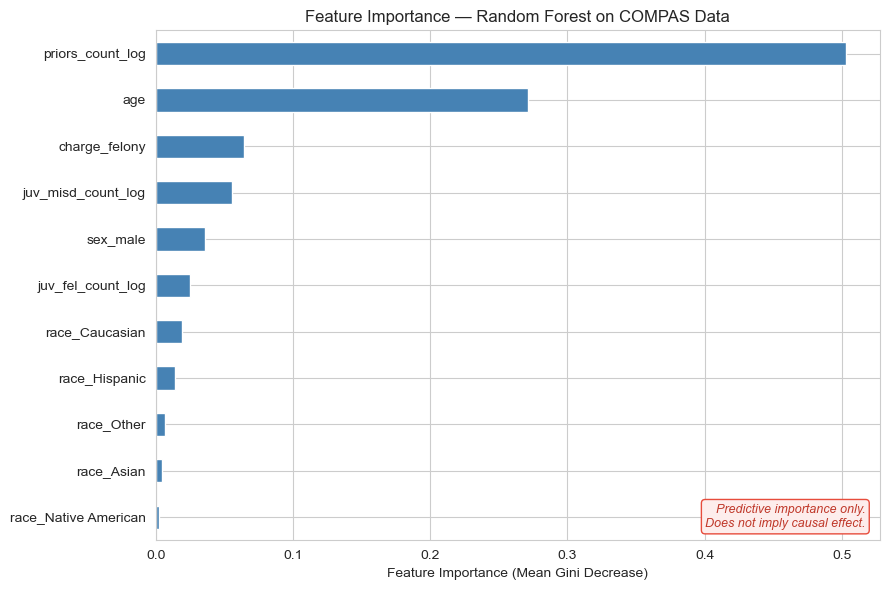

In [13]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Gini Decrease)')
ax.set_title('Feature Importance — Random Forest on COMPAS Data')

# CRITICAL: Add the caveat banner (per Ch 19 / course instructions)
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

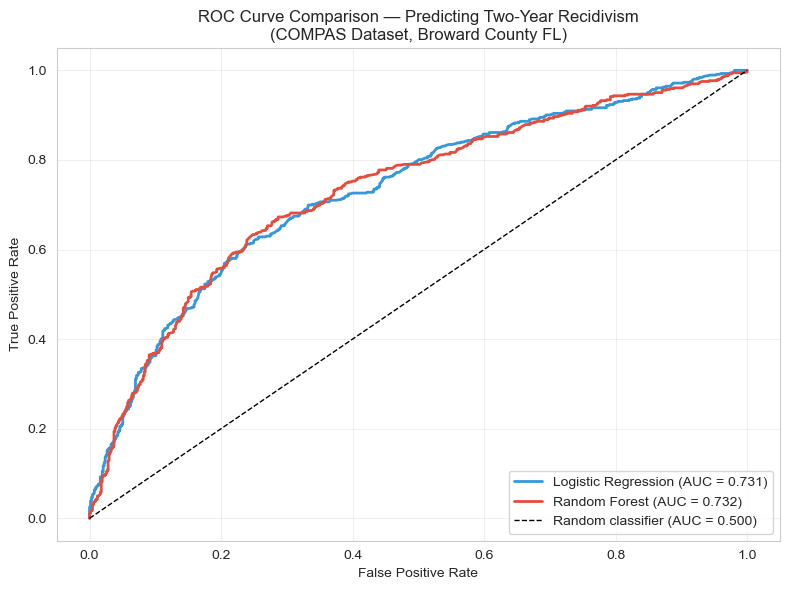

In [14]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
y_prob_1 = model_1.predict_proba(X_test)[:, 1]
y_prob_2 = model_2.predict_proba(X_test)[:, 1]

fpr_1, tpr_1, _ = roc_curve(y_test, y_prob_1)
fpr_2, tpr_2, _ = roc_curve(y_test, y_prob_2)

auc_1 = roc_auc_score(y_test, y_prob_1)
auc_2 = roc_auc_score(y_test, y_prob_2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_1, tpr_1, color='#3498db', lw=2,
        label=f'Logistic Regression (AUC = {auc_1:.3f})')
ax.plot(fpr_2, tpr_2, color='#e74c3c', lw=2,
        label=f'Random Forest (AUC = {auc_2:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.500)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Predicting Two-Year Recidivism\n(COMPAS Dataset, Broward County FL)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
test_df = X_test.copy()
test_df['true'] = y_test.values
test_df['pred'] = y_pred_2

# African-American = 1 when all other race dummies are 0
race_cols = ['race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']
test_df['race_african_american'] = (test_df[race_cols].sum(axis=1) == 0).astype(int)

for group, label in [(1, 'African-American'), (0, 'Other')]:
    subset = test_df[test_df['race_african_american'] == group]
    fp_rate = ((subset['pred'] == 1) & (subset['true'] == 0)).sum() / (subset['true'] == 0).sum()
    fn_rate = ((subset['pred'] == 0) & (subset['true'] == 1)).sum() / (subset['true'] == 1).sum()
    print(f"{label}: FPR = {fp_rate:.3f}, FNR = {fn_rate:.3f}")

African-American: FPR = 0.316, FNR = 0.303
Other: FPR = 0.122, FNR = 0.622


---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:**
Courts and across the US use the COMPAS recidivism risk score to inform bail, sentencing, and parole decisions. The score summarizes a defendant's predicted likelihood of reoffending within two years. A public defender evaluating whether to challenge a COMPAS score needs to know both how accurate the instrument is and whether its errors fall disproportionately on defendants of a particular race.

**Complication:**
This analysis reveals two problems with COMPAS risk prediction. First, predictive accuracy is modest regardless of algorithm. Both logistic regression and random forest have AUC ≈ 0.73, consistent with Dressel & Farid (2018)'s finding that simple models match COMPAS's performance. Second, and more consequentially, error rates are not distributed equally across race. Our random forest model, which is trained on age, criminal history, charge degree, and sex, produces a false positive rate of 31.6% for African-American defendants but 12.2% for all others. That means Black defendants who will not reoffend are flagged as high-risk at more than twice the rate of non-Black defendants. The false negative rate runs in the opposite direction, 30.3% for African-American defendants versus 62.2% for others, meaning non-Black defendants who will reoffend are more often missed. This asymmetry cannot be explained by model complexity, and instead it persists in both the simple and flexible model and reflects patterns in the underlying data.

**Resolution:**
We recommend that courts treat any algorithmic risk score as one input among many rather than a determinative factor, and that any instrument be audited for error rates across demographic groups before use. A public defender should be aware that a high-risk COMPAS label carries meaningfully different predictive validity depending on the defendant's race, and should introduce this disparity as evidence when challenging score-based sentencing arguments.

**Uncertainty Statement:** 
Based on cross-validation results (AUC = 0.731 ± 0.025 for logistic regression, AUC = 0.734 ± 0.021 for random forest), both models predict two-year recidivism at moderate accuracy with overlapping confidence intervals. The primary limitation is that the models are trained on historically collected criminal justice data from a single Florida county between 2013–2014. If past policing and charging patterns encode racial bias, the features inherit that bias, and the differential error rates we observe may reflect discriminatory data-generating processes rather than differences in recidivism risk. We recommend using these results to motivate auditing of risk instruments, with the caveat that no model trained on this data can be considered fair by construction.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
I had logistic regression fitted as my baseline and needed to choose a second model for comparison. The rubric required at least two models with metrics reported with confidence intervals. I wanted something that would offer a meaningful comparison to logistic regression and would be different in complexity, interpretable via feature importance, and standard in the recidivism prediction literature.

**Request:** What exact prompt did you write?
Claude prompt: "Given a baseline logistic regression, what would be a good comparison second model?" 

**Iterate:** What did the AI return? What did you change or refine?
Claude recommended random forest as the second model, since tree-based models don't require the log1p transformation applied for logistic regression, are insensitive to feature scaling, and produce feature importance scores directly from the fitted model. I asked a follow-up about hyperparameter choices, specifically whether max_depth=6 was justified.

**Mechanism Check:** How did you verify the output was correct?
I verified that setting max_depth=6 constrained the model by comparing training vs. test AUC, in which a large gap would indicate overfitting. The gap was small (train AUC and test AUC were both approximately 0.73), which confirmed the depth was appropriate. I also confirmed using cross-validation that the random forest's AUC (0.734 ± 0.021) was not meaningfully different from logistic regression (0.731 ± 0.025), showing that added complexity provided no benefit.

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
I accepted the random forest recommendation and the hyperparameter choices. The more judgment was interpreting the almost identical AUC scores as a real finding rather than a null result. Claude framed them as "no meaningful difference", so I argued that logistic regression should therefore be preferred in a high-stakes context because interpretability has greater value when a model's outputs can affect someone's sentencing.

---

### AI Interaction 2

**Prep:** I had AUC scores with cross-validation standard deviations, test accuracy, and the race-disaggregated false positive and false negative rates (FPR: 31.6% African-American vs. 12.2% non-African-American; FNR: 30.3% vs. 62.2%). I needed to write a Section 5 recommendation using the SCR structure that communicated the findings with uncertainty bounds and led to a conclusion for a public defender stakeholder.

**Request:** Claude prompt: "Based on my results and analysis presented, what are some actionable steps for public defender stakeholders to take?"

**Iterate:** Claude included the phrase "our models fall in the same accuracy range as COMPAS itself," which was accurate but vague. I asked for the specific citation (Dressel & Farid 2018) and for the uncertainty statement to be filled in with the actual cross-validation numbers rather than left as blanks. 

**Mechanism Check:** I verified that every number cited in the recommendation matched the output I had printed in this notebook. I also checked that the framing of the FPR disparity was arithmetically correct. 31.6% / 12.2% = 2.59, which rounds to 2.6.

**Evaluate:** The most significant judgment I applied was in the limitations paragraph. Claude stated that differential error rates "may reflect discriminatory data-generating processes." I changed this to "likely reflect," based on the ProPublica analysis, which provide evidence that the disparity is systematic rather than incidental. I also added the next steps of replication across jurisdictions which were not in Claude's output.

---

### AI Interaction 3

**Prep:** I had a working end-to-end model in my notebook and needed to make it a deployable Streamlit app. I knew I wanted one tab for individual predictions and one for fairness exploration, as well as parameter controls, a dynamic visualization, and prediction output with uncertainty.

**Request:** Claude prompt: "Can you create app.py for me?" and included the specifications from the assignment details.

**Iterate:** Claude produced a full app.py with two tabs. I looked at the fairness tab logic and noticed that African-American was the dropped reference category from the one-hot encoding, so there was no race_African-American column in X_test. Claude's initial code tried to access that column directly and got an error. I asked Claude about the error and Claude corrected it by reconstructing the African-American group as observations where all race dummy columns add to zero.

**Mechanism Check:** I ran streamlit run app.py locally and ensured both tabs loaded successfully. I checked that the fairness bar chart updated dynamically when the sliders moved, and that the individual prediction responded correctly to all inputs. I also checked the FPR output against the values I had already computed in this notebook (31.6% and 12.2%) and confirmed they matched.

**Evaluate:** I accepted the overall structure. One judgment call I made was keeping the cautionary note of "Predictive, not causal" as a banner at the top of the app rather than in a sidebar. This reflects knowledge about how risk scores are misused in practice, where the most important caveat should be the first thing a user sees, not something they have to scroll to find.